In [257]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score 
from sklearn.linear_model import LinearRegression , ElasticNet , Lasso , Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import PowerTransformer
import scipy.stats as stats

warnings.filterwarnings("ignore")

# Finding Basic Characteristics Of DataSet

In [237]:
df = pd.read_csv('concrete_data.csv')
df

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [238]:
df.shape

(1030, 9)

In [239]:
#Remove any whitespaces in column names which can't be seen
df.columns = df.columns.str.strip()

In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [241]:
df.isnull().sum()

cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

In [242]:
#No null values

In [243]:
#Check For duplicates
df.duplicated().sum()

25

In [244]:
df.drop_duplicates(inplace=True)

In [245]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.631343,72.043483,55.536318,182.075323,6.033234,974.376816,772.688259,45.856716,35.250378
std,104.344261,86.170807,64.207969,21.339334,5.919967,77.579667,80.340435,63.734692,16.284815
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,190.700000,0.000000,0.000000,166.600000,0.000000,932.000000,724.300000,7.000000,23.520000
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.800000
75%,349.000000,142.500000,118.300000,192.900000,10.000000,1031.000000,822.200000,56.000000,44.870000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


# Exploratory Data Analysis

<Axes: >

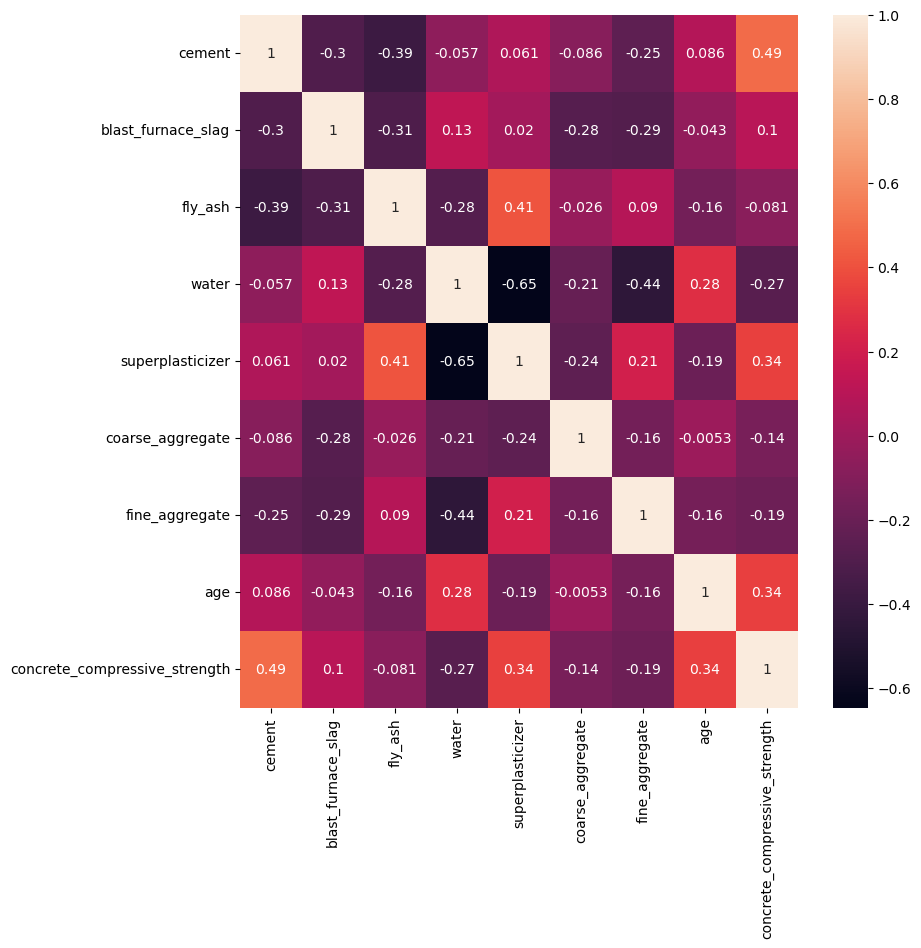

In [246]:
plt.figure(figsize=(9,9))

sns.heatmap(df.corr(), annot=True)

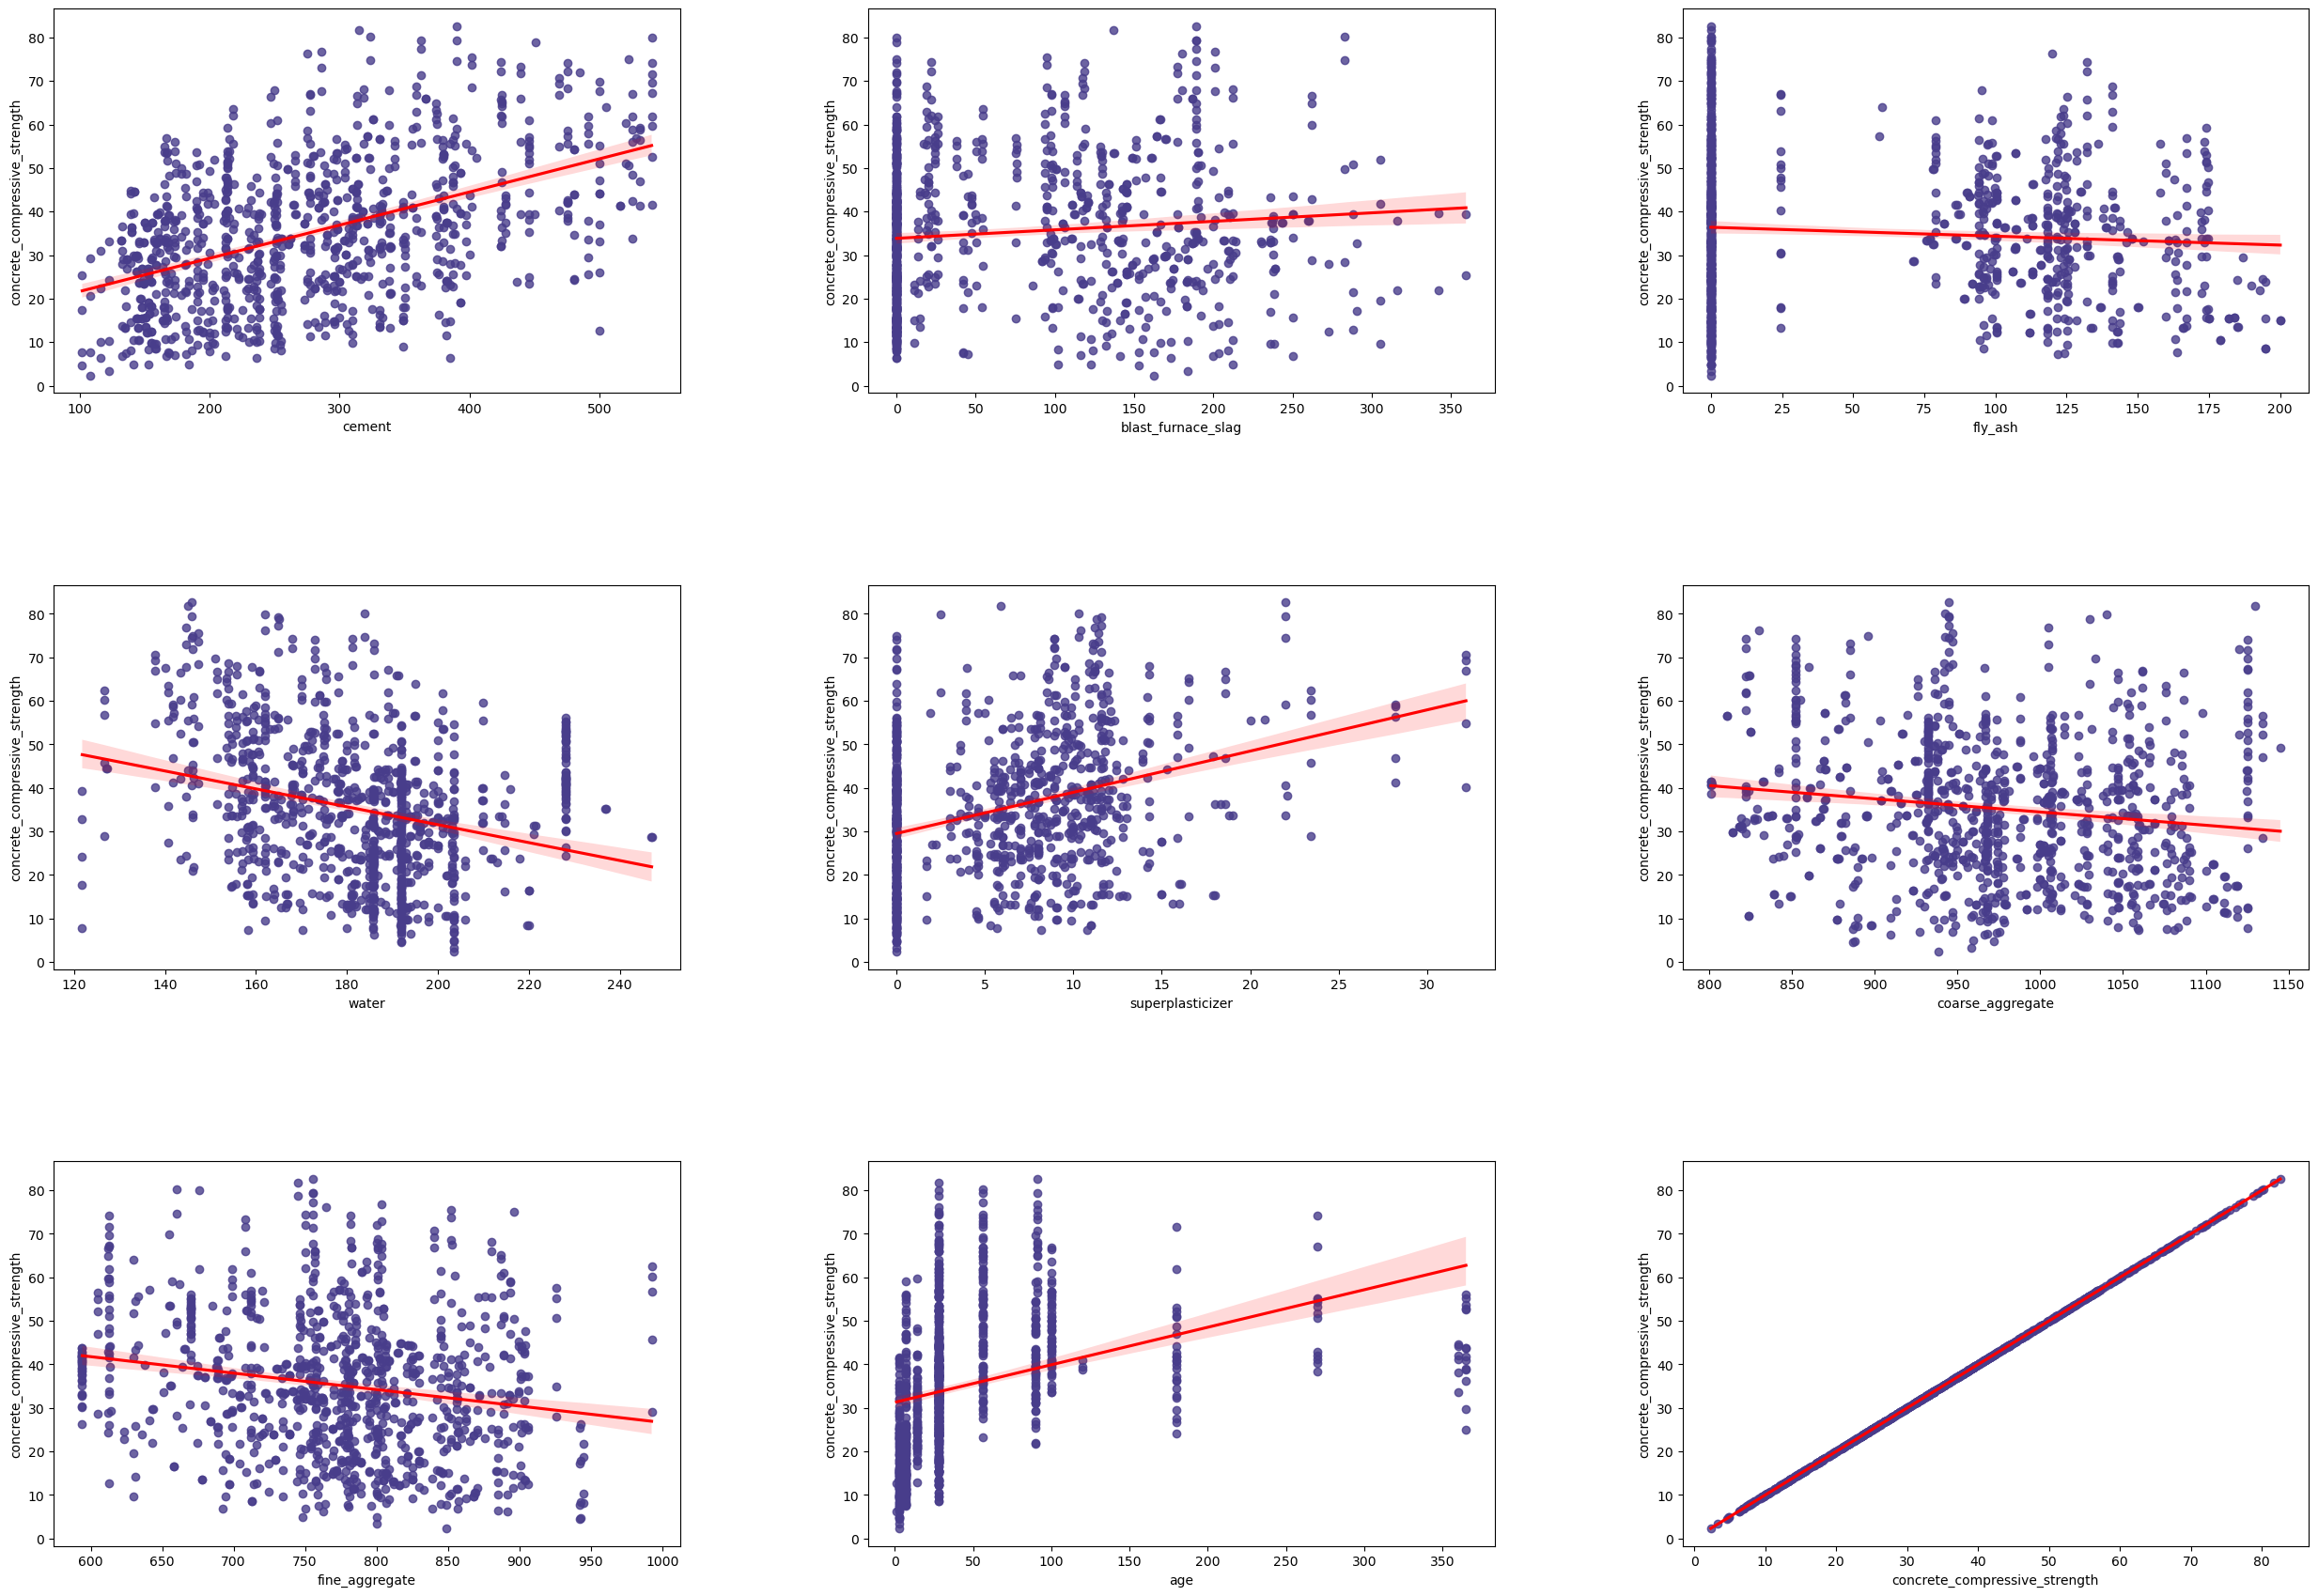

In [247]:
#Plotting the graphs between concrete_compressive_strength and other features

fig = plt.figure(figsize=(30, 50))

plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=1.9, wspace=0.3, hspace=0.5)

for i, col in enumerate(df.columns):

    plt.subplot(15, 3, i + 1)
    
    sns.regplot(x=col, y="concrete_compressive_strength", data=df, scatter_kws={"color": "darkslateblue"}, line_kws={"color": "red"})

plt.show()


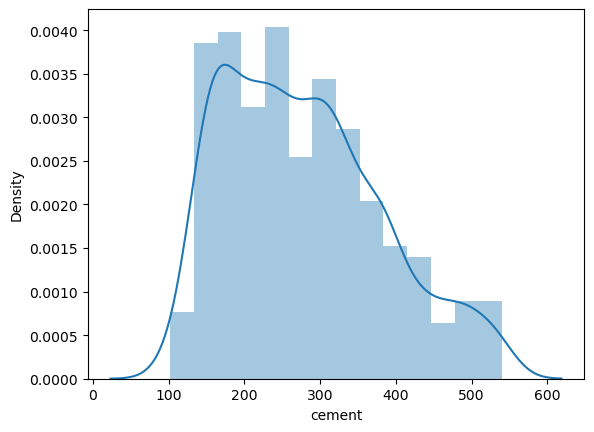

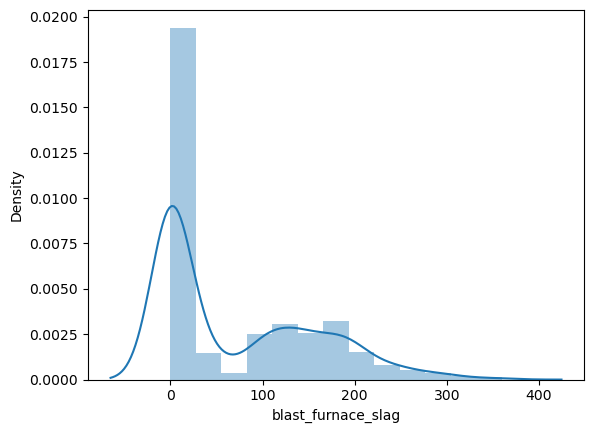

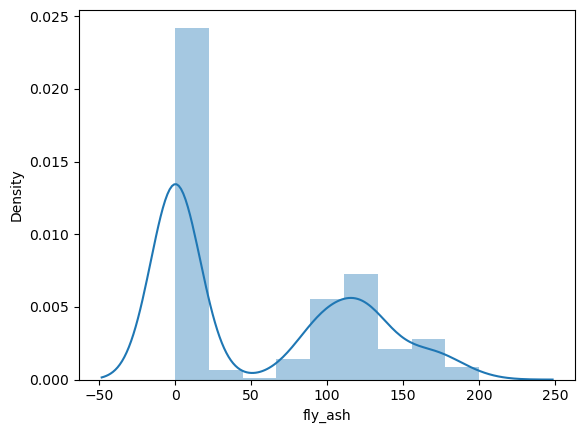

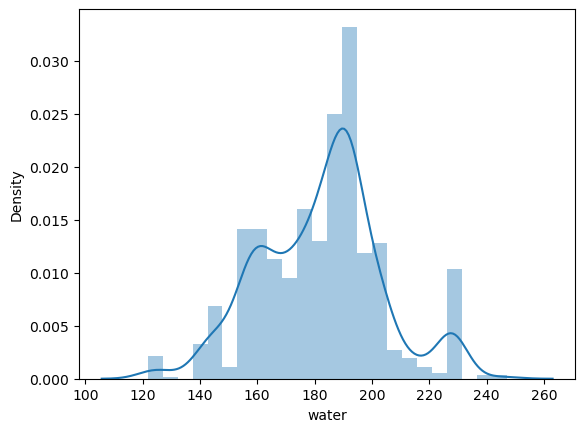

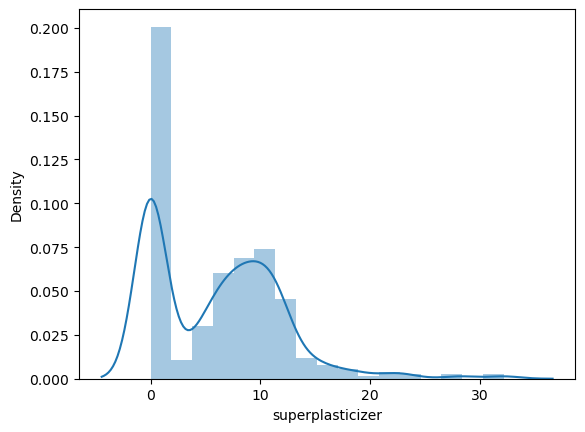

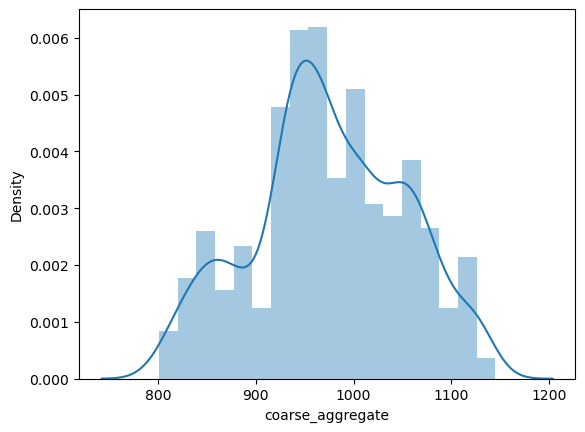

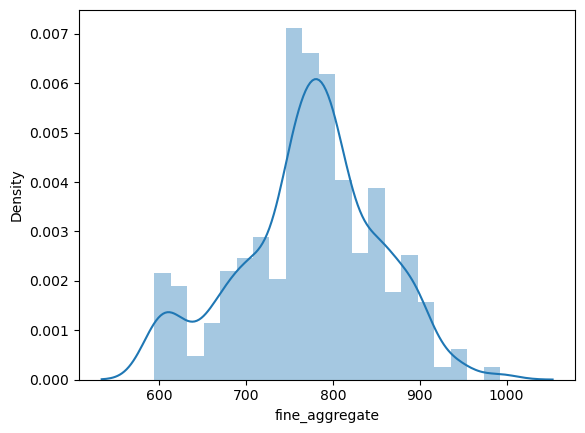

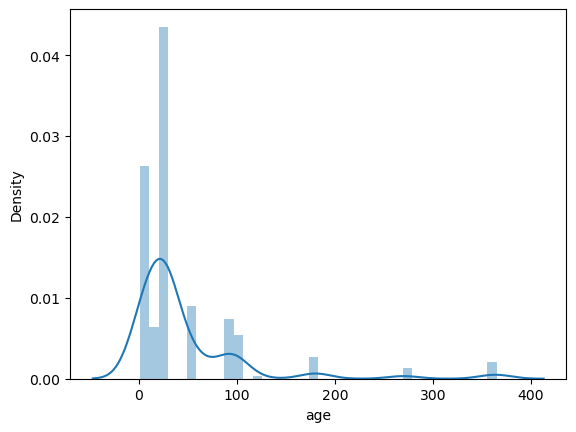

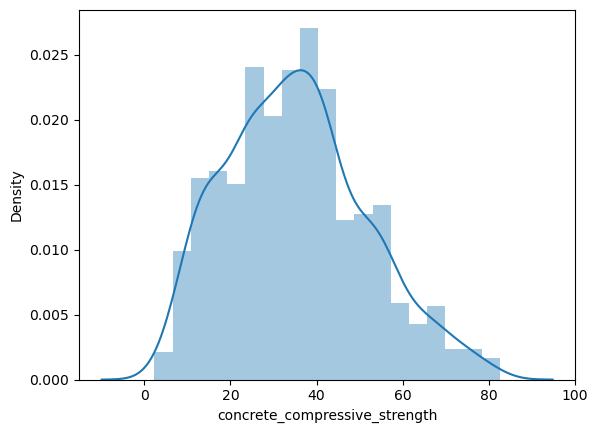

In [256]:
for col in df.columns:
    
    plt.figure()
    sns.distplot(df[col])
    plt.show()

# Splitting Dataset into Training and Test

In [249]:
X = df.drop(["concrete_compressive_strength"], axis=1)
Y = df["concrete_compressive_strength"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

# Normalizing The DataSet

In [250]:
trans = PowerTransformer()
X_train = trans.fit_transform(X_train)
X_test = trans.transform(X_test)

In [251]:
z1 = np.abs(stats.zscore(X_train))
z2 = np.abs(stats.zscore(X_test))

X_train = X_train[(z1<3).all(axis=1)]
Y_train = Y_train[(z1<3).all(axis=1)]
X_test = X_test[(z2<3).all(axis=1)]
Y_test = Y_test[(z2<3).all(axis=1)]


X_test.shape


(302, 8)

In [252]:
linear = LinearRegression()
elastic = ElasticNet()
lasso  = Lasso()
ridge = Ridge()
polynomial = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())

clf = [linear,elastic,lasso,ridge,polynomial]
hashmap={}

In [253]:
def compute(model):
    model.fit(X_train,Y_train)
    Y_pred = model.predict(X_test)
    r2=r2_score(Y_test,Y_pred)
    rmse=np.sqrt(mean_squared_error(Y_test,Y_pred))
    hashmap[str(model)]=(r2,rmse)

In [254]:
for i in clf:
    compute(i)

In [255]:
score=pd.DataFrame(hashmap)
score = score.transpose()
score.columns=['R2_score','RMSE']
score = score.sort_values('R2_score',ascending=False)
score

,R2_score,RMSE
"Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),\n ('linearregression', LinearRegression())])",0.852955,6.501241
LinearRegression(),0.780560,7.941984
Ridge(),0.780543,7.942301
Lasso(),0.750541,8.467813
ElasticNet(),0.644415,10.109816
